In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import matplotlib.ticker as ticker
import pickle
import torch
from torch import nn
OUTPUT_DIR = Path("./data/generated_outputs")
FIG_DIR = Path("./figures")
FIG_DIR.mkdir(exist_ok=True, parents=True)
RESULTS_DIR = Path("./results")
FIG_DIR = Path("./figures")
model_df = pd.read_csv(OUTPUT_DIR / "processed_data_merged.csv")
model_df["endtime"] = pd.to_datetime(model_df["endtime"])
import shap
sns.set_theme(style="whitegrid")

# Visualizations of Cleaned Data
#### In this section, I will present several visualizations to illustrate the processed data.

#### Weekly cases during the survey period

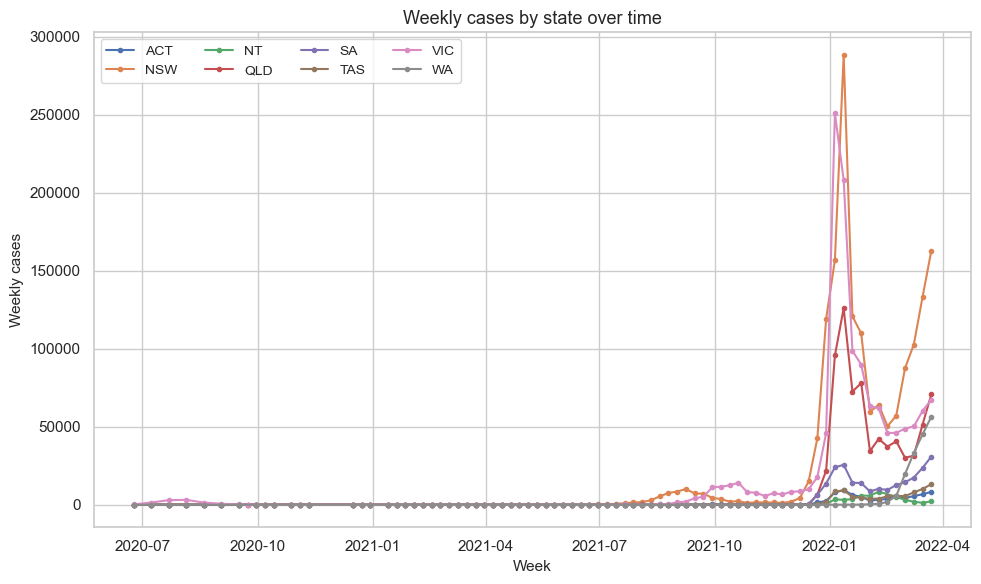

In [2]:
plot_df = model_df.copy()
plot_df["endtime"] = pd.to_datetime(plot_df["endtime"])
inverse_state_mapping = {
    "New South Wales": "NSW",
    "Victoria": "VIC",
    "Queensland": "QLD",
    "South Australia": "SA",
    "Western Australia": "WA",
    "Tasmania": "TAS",
    "Northern Territory": "NT",
    "Australian Capital Territory": "ACT"
}
plot_df["state_abbrev"] = plot_df["state"].map(inverse_state_mapping)

baseline_date = plot_df["endtime"].min().floor("D")
plot_df["response_week"] = baseline_date + pd.to_timedelta(((plot_df["endtime"] - baseline_date).dt.days // 7) * 7, unit="D")

cases_weekly = plot_df.groupby(["state_abbrev", "response_week"])["daily_cases"].mean().reset_index()
cases_weekly["state_weekly_cases"] = cases_weekly["daily_cases"] * 7

state_order = ["ACT", "NSW", "NT", "QLD", "SA", "TAS", "VIC", "WA"]
plt.figure(figsize=(10, 6))

for state_abbrev in state_order:
    grp = cases_weekly[cases_weekly["state_abbrev"] == state_abbrev]
    if not grp.empty:
        plt.plot(grp["response_week"], grp["state_weekly_cases"], label=state_abbrev, marker='o', markersize=3)

plt.title("Weekly cases by state over time", fontsize=13)
plt.xlabel("Week", fontsize=11)
plt.ylabel("Weekly cases", fontsize=11)
plt.legend(ncol=4, fontsize=10)
plt.tight_layout()

plt.savefig(FIG_DIR / "weekly_cases_by_state.png", dpi=300)
plt.show()

#### Weekly vaccinations during the survey period

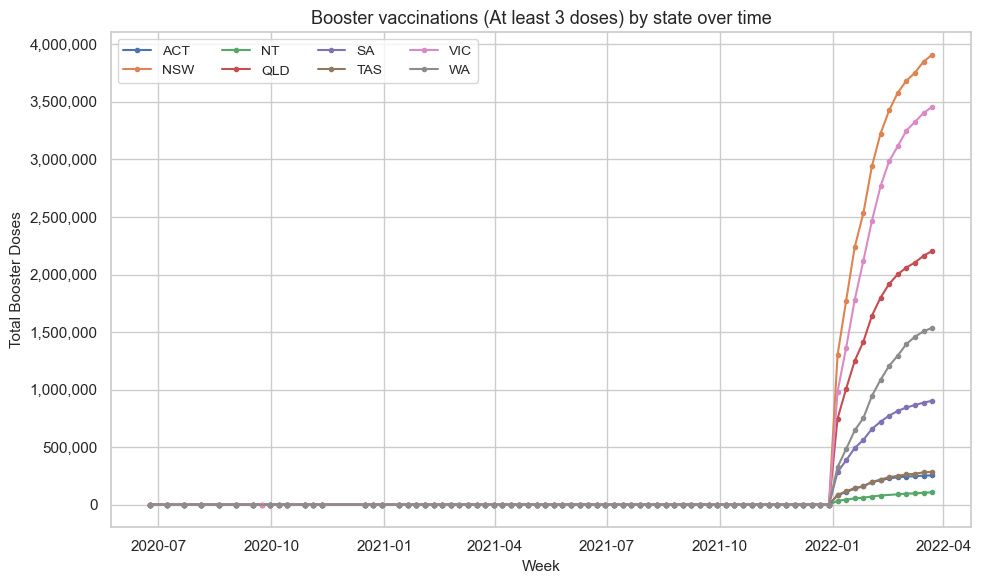

In [3]:
plot_df["state_abbrev"] = plot_df["state"].map(inverse_state_mapping)
weekly = plot_df.groupby(["state_abbrev", "response_week"])["at_least_3_doses"].max().reset_index()
plt.figure(figsize=(10, 6))
for state_abbrev in state_order:
    grp = weekly[weekly["state_abbrev"] == state_abbrev]
    if not grp.empty:
        plt.plot(grp["response_week"], grp["at_least_3_doses"], label=state_abbrev, marker='o', markersize=3)

plt.gca().yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, p: format(int(x), ',')))

plt.title("Booster vaccinations (At least 3 doses) by state over time", fontsize=13)
plt.xlabel("Week", fontsize=11)
plt.ylabel("Total Booster Doses", fontsize=11)
plt.legend(ncol=4, fontsize=10)
plt.tight_layout()

plt.savefig(FIG_DIR / "weekly_vaccines_by_state.png", dpi=300)
plt.show()

## Figure1 in the report
This line chart provides a visual summary of the fortnighrly trends in public compliance with protective behaviors from mid-2020 to early 2022.

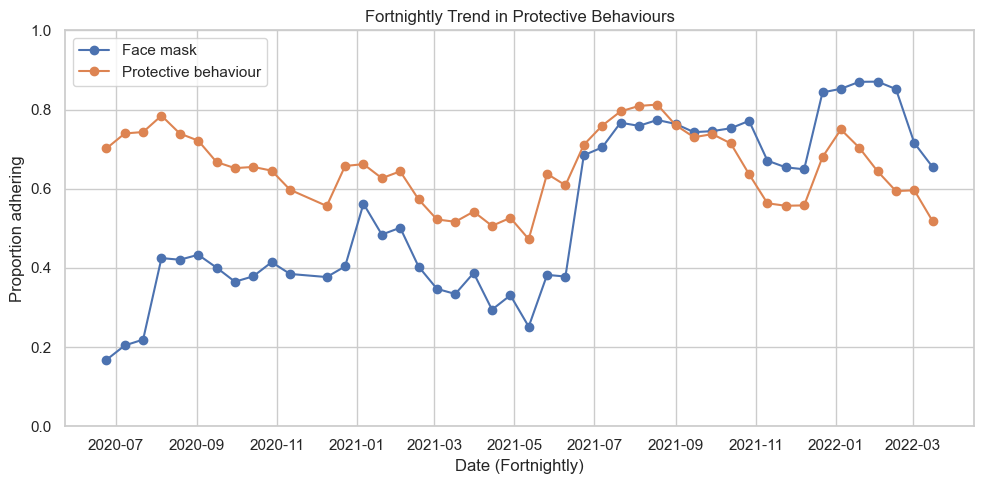

In [4]:
plot_df = model_df.copy()

# Convert categorical binary outcomes to numerical
plot_df["face_mask_yes"] = (plot_df["face_mask_bi"] == "Yes").astype(int)
plot_df["protective_yes"] = (plot_df["protective_behaviour_nomask_bi"] == "Yes").astype(int)

# Calculate the start date for each 14-day window
baseline_date = plot_df["endtime"].min().floor("D")
plot_df["fortnight_start"] = baseline_date + pd.to_timedelta(
    ((plot_df["endtime"] - baseline_date).dt.days // 14) * 14, unit="D"
)

fortnightly_summary = (
    plot_df.groupby("fortnight_start")[["face_mask_yes", "protective_yes"]]
    .mean()
    .reset_index()
)


plt.figure(figsize=(10, 5))
plt.plot(
    fortnightly_summary["fortnight_start"], 
    fortnightly_summary["face_mask_yes"], 
    label="Face mask", 
    marker="o"
)
plt.plot(
    fortnightly_summary["fortnight_start"], 
    fortnightly_summary["protective_yes"], 
    label="Protective behaviour", 
    marker="o"
)

plt.ylabel("Proportion adhering")
plt.xlabel("Date (Fortnightly)")
plt.title("Fortnightly Trend in Protective Behaviours")
plt.ylim(0, 1)
plt.legend()
plt.tight_layout()
plt.show()

#### This bar chart illustrates the sample size distribution of the binary indicator during_mandate.

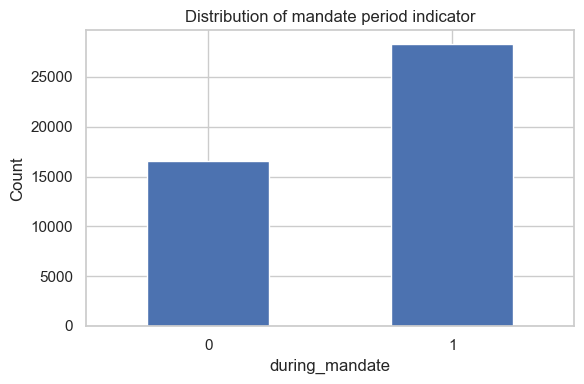

In [5]:
plt.figure(figsize=(6, 4))
plot_df["during_mandate"].value_counts().sort_index().plot(kind="bar")
plt.title("Distribution of mandate period indicator")
plt.xlabel("during_mandate")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


## Figure2 in the report
The proportion of respondents frequently wearing face masks before and after the implementation of mask mandates.

<Figure size 800x600 with 0 Axes>

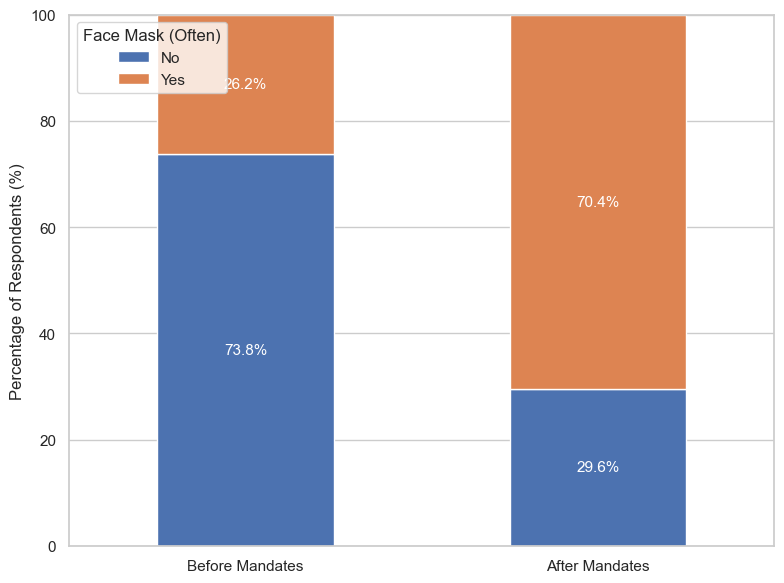

In [6]:
plot_df = model_df.copy()
plot_df['Mandate Status'] = plot_df['during_mandate'].map({
    0: 'Before Mandates', 
    1: 'After Mandates'
})

# calculate percentages and reshape for stacked bar
summary_df = (
    plot_df.groupby('Mandate Status')['face_mask_bi']
    .value_counts(normalize=True)
    .mul(100)
    .unstack()
)
summary_df = summary_df.reindex(['Before Mandates', 'After Mandates'])


plt.figure(figsize=(8, 6))
ax = summary_df.plot(kind='bar', stacked=True, figsize=(8, 6))

plt.ylabel('Percentage of Respondents (%)', fontsize=12)
plt.xlabel('')
plt.xticks(rotation=0)
plt.legend(title='Face Mask (Often)', fontsize=11, loc='upper left')
plt.ylim(0, 100)

# Add centered percentage labels to each bar section
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', label_type='center', fontsize=11, color='white')

plt.tight_layout()
plt.savefig(FIG_DIR / "mask_mandate_impact.png", dpi=300)
plt.show()

#### Comparison of missing data handling strategies (XGBoost)

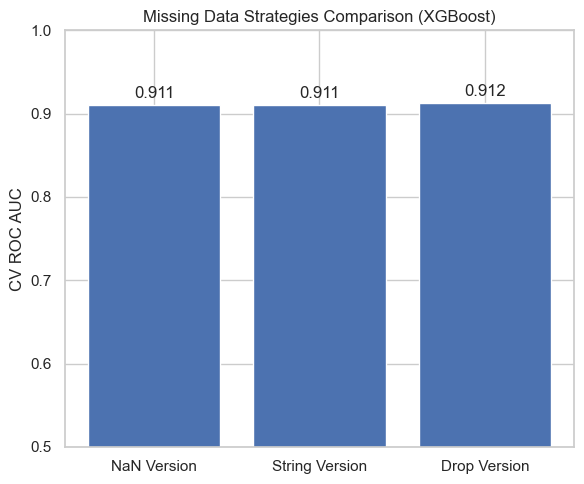

In [7]:
exp_names = ["exp_nan", "exp_str", "exp_drop"]
strategy_names = ['NaN Version', 'String Version', 'Drop Version']
strategy_aucs = []

for exp_name in exp_names:
    with open(RESULTS_DIR / f"{exp_name}_face_mask_XGBoost.pkl", "rb") as f:
        cv_results = pickle.load(f)
        strategy_aucs.append(max(cv_results['mean_test_roc_auc']))

plt.figure(figsize=(6, 5))
bars2 = plt.bar(strategy_names, strategy_aucs)
plt.ylim(0.5, 1.0)
plt.ylabel('CV ROC AUC')
plt.title('Missing Data Strategies Comparison (XGBoost)')
for bar in bars2:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.005, f'{yval:.3f}', ha='center', va='bottom')
plt.tight_layout()
plt.savefig(FIG_DIR / "missing_data_strategies.png", dpi=300)
plt.show()

#### Comparison of the four predictive models based on ROC AUC scores

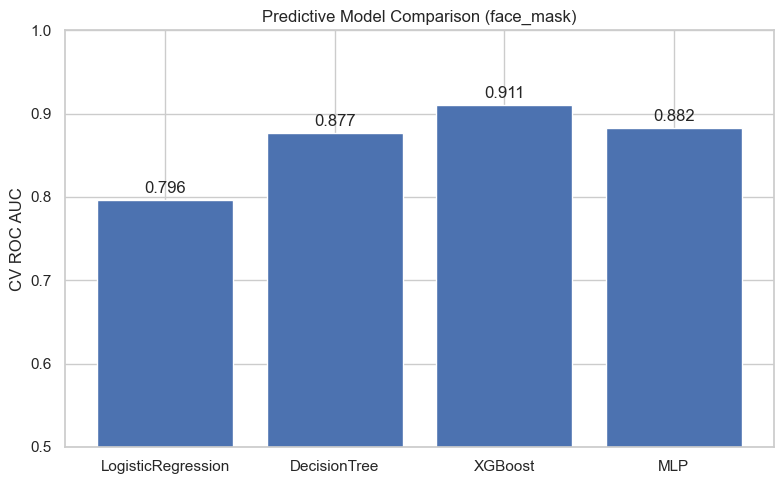

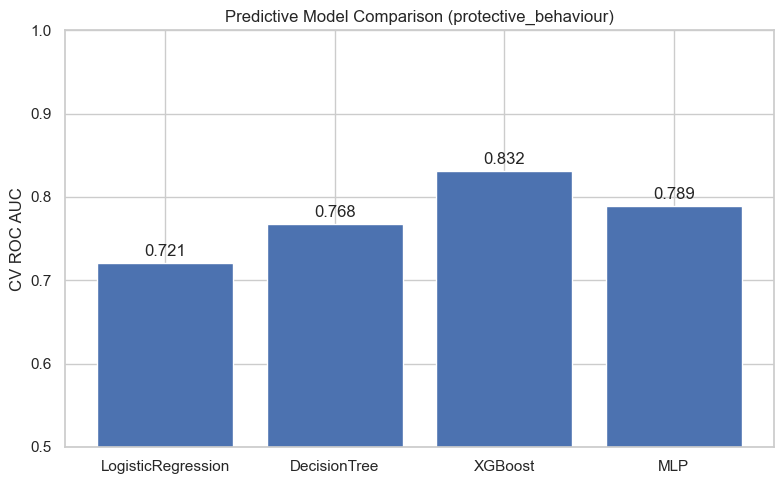

In [8]:
model_names = ['LogisticRegression', 'DecisionTree', 'XGBoost', 'MLP']
model_aucs = []
targets = ['face_mask', 'protective_behaviour']

for target_name in targets:
    model_aucs = []
    for m_name in model_names:
        file_path = RESULTS_DIR / f"exp_str_{target_name}_{m_name}.pkl"
        
        with open(file_path, "rb") as f:
            cv_results = pickle.load(f)
            best_auc = np.nanmax(cv_results['mean_test_roc_auc']) 
            model_aucs.append(best_auc)
            
    plt.figure(figsize=(8, 5))
    bars = plt.bar(model_names, model_aucs)
    plt.ylim(0.5, 1.0)
    plt.ylabel('CV ROC AUC')
    plt.title(f'Predictive Model Comparison ({target_name})')
    
    for bar in bars:
        yval = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, yval + 0.005, f'{yval:.3f}', ha='center', va='bottom')
        
    plt.tight_layout()
    plt.savefig(FIG_DIR / f"model_comparison_{target_name}.png", dpi=300)
    plt.show()


### Comparing COVID-19 cases and protective behaviors.


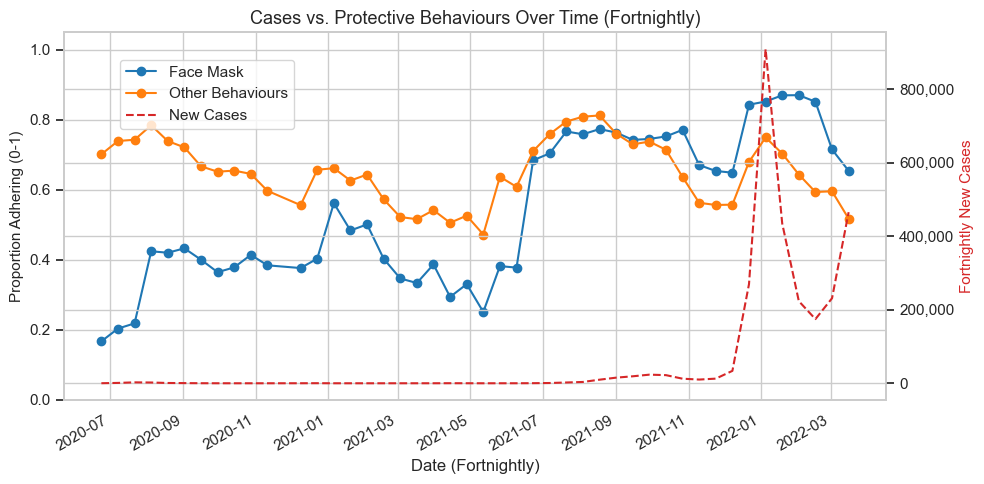

In [9]:

plot_df["face_mask_yes"] = (plot_df["face_mask_bi"] == "Yes").astype(int)
plot_df["protective_yes"] = (plot_df["protective_behaviour_nomask_bi"] == "Yes").astype(int)
baseline_date = plot_df["endtime"].min().floor("D")
plot_df["fortnight_start"] = baseline_date + pd.to_timedelta(
    ((plot_df["endtime"] - baseline_date).dt.days // 14) * 14, unit="D"
)

# Behaviour: calculate the mean proportion
fortnightly_rates = plot_df.groupby("fortnight_start")[["face_mask_yes", "protective_yes"]].mean()
# Cases: drop duplicated respondents on the same day/state to get true daily cases, then sum
fortnightly_cases = plot_df.drop_duplicates(subset=["endtime", "state"]).groupby("fortnight_start")["daily_cases"].sum()
fig, ax1 = plt.subplots(figsize=(10, 5))


fortnightly_rates.plot(ax=ax1, marker='o', color=['tab:blue', 'tab:orange'])
ax1.set_ylabel("Proportion Adhering (0-1)", fontsize=11)
ax1.set_ylim(0, 1.05)
ax1.set_xlabel("Date (Fortnightly)")


ax2 = ax1.twinx()
fortnightly_cases.plot(ax=ax2, color='tab:red', linestyle='--')
ax2.set_ylabel("Fortnightly New Cases", color='tab:red', fontsize=11)
ax2.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, p: format(int(x), ','))) # Add commas


plt.title("Cases vs. Protective Behaviours Over Time (Fortnightly)", fontsize=13)
ax1.get_legend().remove() # Remove pandas default legend to avoid mess
fig.legend(["Face Mask", "Other Behaviours", "New Cases"], loc='upper left', bbox_to_anchor=(0.12, 0.88))

plt.tight_layout()
plt.savefig(FIG_DIR / "cases_vs_behaviours_fortnightly.png", dpi=300)
plt.show()

### Comparing vaccinations and protective behaviors (Fortnightly).

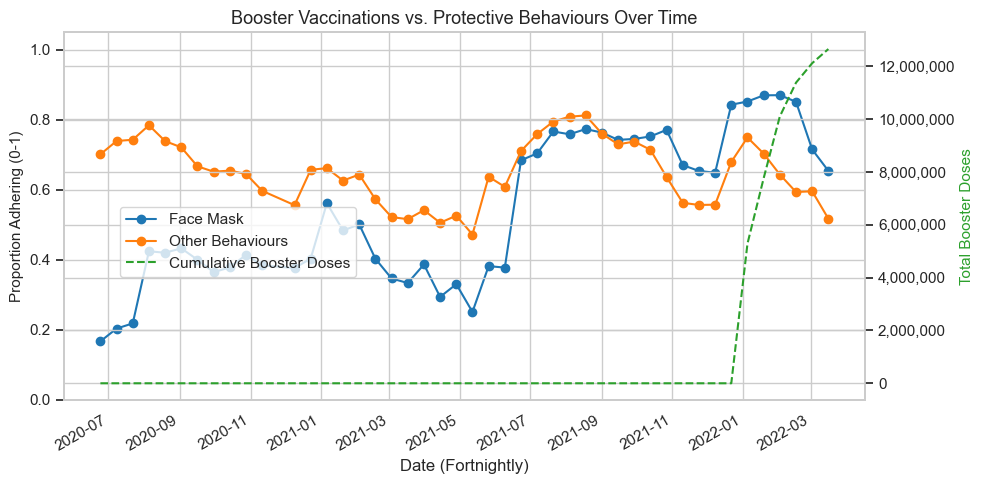

In [10]:
plot_df["face_mask_yes"] = (plot_df["face_mask_bi"] == "Yes").astype(int)
plot_df["protective_yes"] = (plot_df["protective_behaviour_nomask_bi"] == "Yes").astype(int)
baseline_date = plot_df["endtime"].min().floor("D")
plot_df["fortnight_start"] = baseline_date + pd.to_timedelta(
    ((plot_df["endtime"] - baseline_date).dt.days // 14) * 14, unit="D"
)

fortnightly_rates = plot_df.groupby("fortnight_start")[["face_mask_yes", "protective_yes"]].mean()
fortnightly_vax = plot_df.groupby(["fortnight_start", "state"])["at_least_3_doses"].max().groupby(level=0).sum()


fig, ax1 = plt.subplots(figsize=(10, 5))


fortnightly_rates.plot(ax=ax1, marker='o', color=['tab:blue', 'tab:orange'])
ax1.set_ylabel("Proportion Adhering (0-1)", fontsize=11)
ax1.set_ylim(0, 1.05)
ax1.set_xlabel("Date (Fortnightly)")

ax2 = ax1.twinx()
fortnightly_vax.plot(ax=ax2, color='tab:green', linestyle='--')
ax2.set_ylabel("Total Booster Doses", color='tab:green', fontsize=11)
ax2.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, p: format(int(x), ',')))

plt.title("Booster Vaccinations vs. Protective Behaviours Over Time", fontsize=13)
ax1.get_legend().remove()
# Legend position adjusted to 'center left' to avoid overlapping with the rising vaccine line
fig.legend(["Face Mask", "Other Behaviours", "Cumulative Booster Doses"], loc='center left', bbox_to_anchor=(0.12, 0.5))

plt.tight_layout()
plt.savefig(FIG_DIR / "vax_vs_behaviours_fortnightly.png", dpi=300)
plt.show()

In [11]:
def format_feature_name(raw_name):
    exact_mapping = {
        'protective_behaviour_nomask_scale': 'Protective Behaviour',
        'week_number': 'Week Number',
        'age': 'Age',
        'household_size': 'Household Size',
        'cantril_ladder': 'Cantril Ladder',
        'r1_1': 'Perceived Susceptibility',
        'r1_2': 'Perceived Severity',
        'i2_health': 'Non-Household Contacts',
        'during_mandate': 'Mandate Period'
    }
    if raw_name in exact_mapping:
        return exact_mapping[raw_name]

    prefix_mapping = {
        'gender_': 'Gender',
        'employment_status_': 'Employment Status',
        'WCRex1_': 'Government Handling',
        'WCRex2_': 'Confidence in response',
        'i9_health_': 'Isolate If Unwell',
        'i11_health_': 'Willingness To Isolate',
        'PHQ4_1_': 'Little interest or pleasure',
        'PHQ4_2_': 'Feeling down or depressed',
        'PHQ4_3_': 'Feeling nervous or anxious',
        'PHQ4_4_': 'Worrying',
        'd1_comorbidities_': 'Comorbidities'
    }
    for prefix, clean_base in prefix_mapping.items():
        if raw_name.startswith(prefix):
            suffix = raw_name[len(prefix):]
            return f"{clean_base} ({suffix})"
    return raw_name

## Figure 8 in the report
Beeswarm plot (Shows feature impact distribution)(Face Mask)

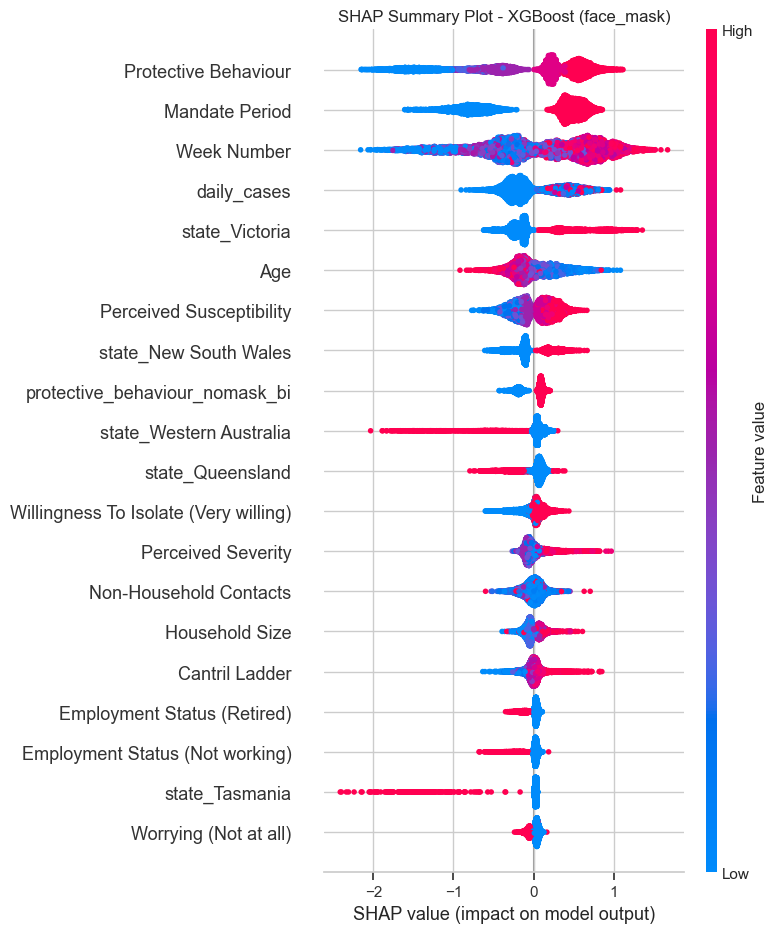

In [12]:
model_name = "XGBoost" 
target_name = 'face_mask'

data_path = RESULTS_DIR / f"{model_name}_{target_name}_shap_data.pkl"
with open(data_path, "rb") as f:
    shap_data = pickle.load(f)

shap_values = shap_data["shap_values"]
X_test_features = shap_data["X_test_features"]
X_test_features.columns = [format_feature_name(col) for col in X_test_features.columns]
plt.rcParams.update({'font.size': 12})

plt.figure(figsize=(10, 10))
shap.summary_plot(shap_values, X_test_features, show=False, plot_type="dot")
plt.title(f"SHAP Summary Plot - {model_name} ({target_name})")
plt.tight_layout()
plt.savefig(FIG_DIR / f"{model_name}_{target_name}_shap_beeswarm.png", dpi=300, bbox_inches='tight')
plt.show()


### Bar plot (Shows average global importance) (Face mask)

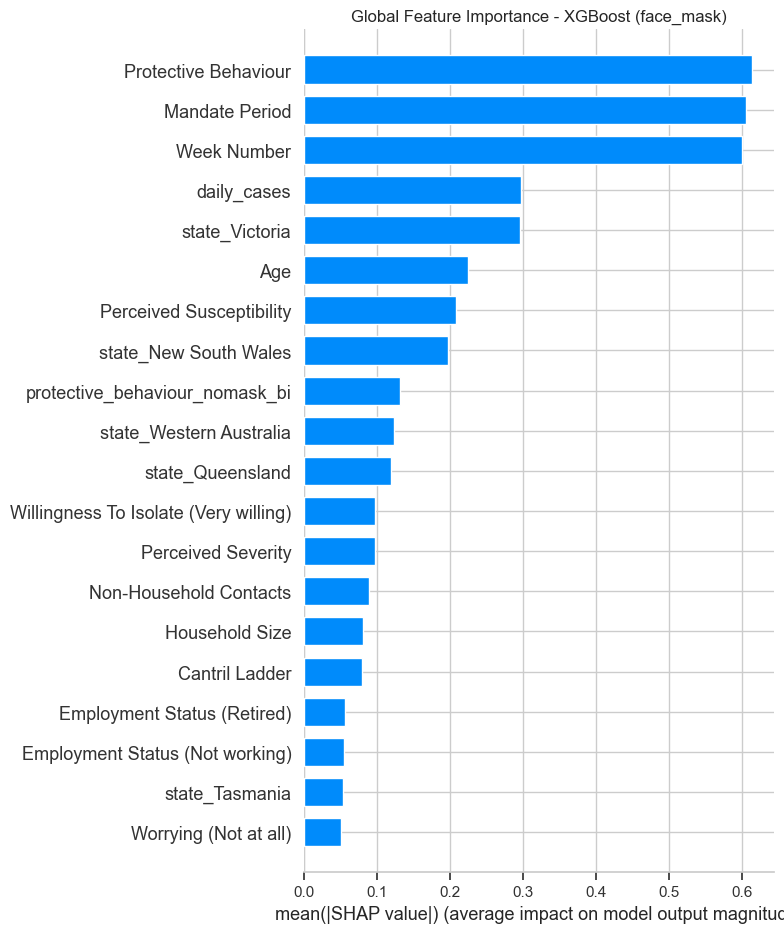

In [13]:
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_test_features, show=False, plot_type="bar")
plt.title(f"Global Feature Importance - {model_name} ({target_name})")
plt.tight_layout()
plt.savefig(FIG_DIR / f"{model_name}_{target_name}_shap_bar.png", dpi=300, bbox_inches='tight')
plt.show()

## Figure 9 in the report
SHAP Beeswarm Plot (Protective Behaviour)

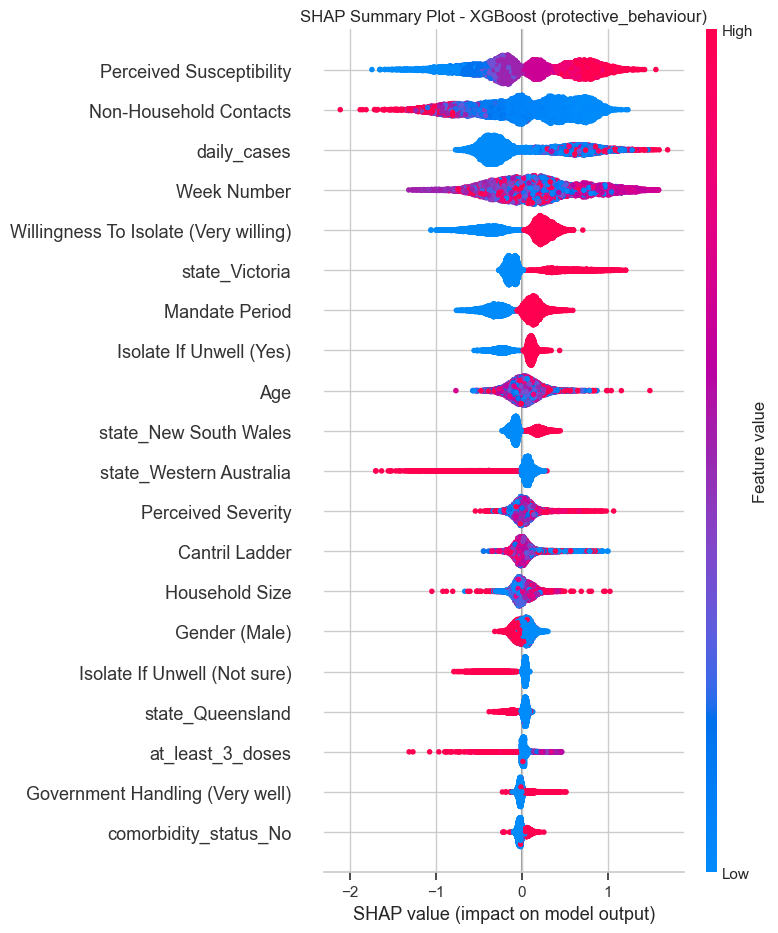

In [14]:
target_name = 'protective_behaviour'
model_name = "XGBoost" 

data_path = RESULTS_DIR / f"{model_name}_{target_name}_shap_data.pkl"
with open(data_path, "rb") as f:
    shap_data = pickle.load(f)

shap_values = shap_data["shap_values"]
X_test_features = shap_data["X_test_features"]
X_test_features.columns = [format_feature_name(col) for col in X_test_features.columns]
plt.rcParams.update({'font.size': 12})

plt.figure(figsize=(10, 10))
shap.summary_plot(shap_values, X_test_features, show=False, plot_type="dot")
plt.title(f"SHAP Summary Plot - {model_name} ({target_name})")
plt.tight_layout()
plt.savefig(FIG_DIR / f"{model_name}_{target_name}_shap_beeswarm.png", dpi=300, bbox_inches='tight')
plt.show()

### SHAP Bar Plot (Protective Behaviour)

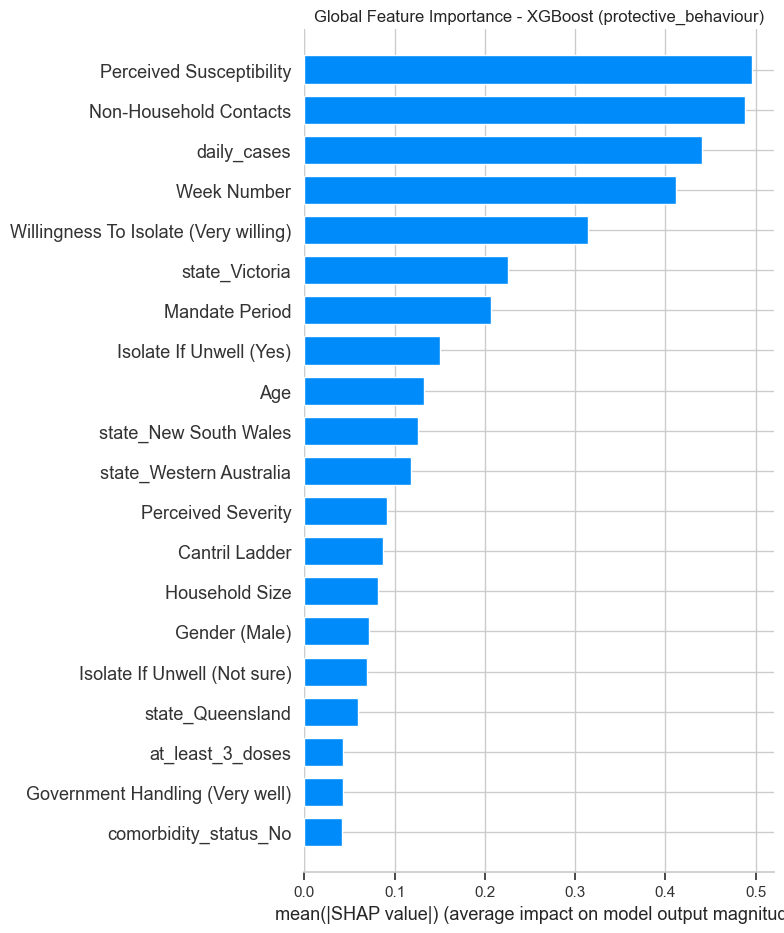

In [15]:
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_test_features, show=False, plot_type="bar")
plt.title(f"Global Feature Importance - {model_name} ({target_name})")
plt.tight_layout()
plt.savefig(FIG_DIR / f"{model_name}_{target_name}_shap_bar.png", dpi=300, bbox_inches='tight')
plt.show()

#### This figure depicts the training curve of the best hyperparameters in the MLP model

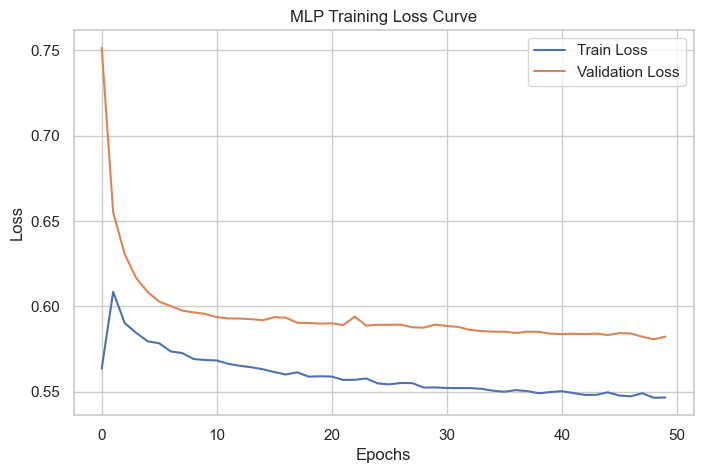

In [16]:
class MLP(nn.Module):
    def __init__(self, input_dim, hidden_size_1=50, hidden_size_2=25, hidden_size_3=10, dropout_rate=0.2, activation=nn.ReLU): 
        super().__init__()
        self.hidden_size_2 = hidden_size_2
        self.hidden_size_3 = hidden_size_3
        
        # First hidden layer
        self.layer1 = nn.Sequential(
            nn.Linear(input_dim, hidden_size_1),
            activation(), 
            nn.Dropout(dropout_rate)
        )
        last_out_dim = hidden_size_1
        
        # Second hidden layer
        if self.hidden_size_2 > 0:
            self.layer2 = nn.Sequential(
                nn.Linear(last_out_dim, hidden_size_2),
                activation(),
                nn.Dropout(dropout_rate)
            )
            last_out_dim = hidden_size_2
            
            # Third hidden layer
            if self.hidden_size_3 > 0:
                self.layer3 = nn.Sequential(
                    nn.Linear(last_out_dim, hidden_size_3),
                    activation(),
                    nn.Dropout(dropout_rate)
                )
                last_out_dim = hidden_size_3
                
        # Output layer 
        self.output_layer = nn.Linear(last_out_dim, 1)

    def forward(self, X):
        if not isinstance(X, torch.Tensor):
            X = torch.tensor(X, dtype=torch.float32)
            
        out = self.layer1(X)
        if self.hidden_size_2 > 0:
            out = self.layer2(out)
            if self.hidden_size_3 > 0:
                out = self.layer3(out)
                
        return self.output_layer(out)


MODEL_DIR = Path("./models")
model_path = MODEL_DIR / "exp_str_protective_behaviour_MLP_final.pkl"

with open(model_path, "rb") as f:
    best_pipeline = pickle.load(f)
mlp_clf = best_pipeline.named_steps['classifier']


history = mlp_clf.history
train_loss = history[:, 'train_loss']
valid_loss = history[:, 'valid_loss'] 

plt.figure(figsize=(8, 5))
plt.plot(train_loss, label='Train Loss')
if valid_loss:
    plt.plot(valid_loss, label='Validation Loss')
plt.title('MLP Training Loss Curve')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()